# Comparing classifiers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from results_functions import grand_average, plot_all_patients, get_scores_all_patients
from db import patients_db
import pandas as pd
import seaborn as sns


## Read all scores from the dataframes

In [ ]:
def read_all_ews_scores(dataframe_name = ""):
    df = pd.read_csv(dataframe_name)
    ews_scores = df['ews'] 
    ews_scores = ews_scores.tolist()
    return ews_scores

# Read the CSV file
directory = "storage/classifiers/"
ews_scores_aphasia_slda = read_all_ews_scores(directory+"aphasia_sldadata.csv")
ews_scores_static = read_all_ews_scores(directory+"staticdata.csv")
# ews_scores_window4 = read_all_ews_scores(directory+"window4data.csv") # not part of the thesis, but experimental (window size = previous session)
ews_scores_window5 = read_all_ews_scores(directory+"window5data.csv")
ews_scores_transfer = read_all_ews_scores(directory+"transferdata.csv")
ews_scores_cc = read_all_ews_scores(directory+"ccdata.csv")


print(len(ews_scores_aphasia_slda))



149


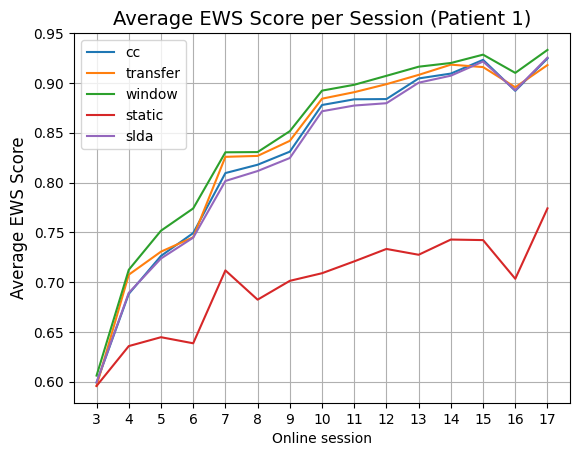

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ews_scores_cc[:15], label="cc")
plt.plot(ews_scores_transfer[:15], label="transfer")
plt.plot(ews_scores_window4[:15], label="window")
plt.plot(ews_scores_static[:15], label="static")
plt.plot(ews_scores_aphasia_slda[:15], label="slda")

plt.ylabel("EWS Score", fontsize=12)
plt.title("EWS Score per Session (Patient 1)", fontsize=14)
plt.xticks(np.arange(0,15,1), np.arange(3,18,1))
plt.xlabel("Online session")
plt.grid()
plt.legend()
plt.show()

In [8]:
# Testing for significance without correcting for multiple tests
from scipy.stats import wilcoxon
import numpy as np

# Epoch-wise performance ----------------------------------------------------------

# Baseline versions
name_baseline_1 = "Transfer Fixed BT-LDA"
name_baseline_2 = "Adaptive CC sLDA"
ews_baseline_1 = ews_scores_transfer
ews_baseline_2 = ews_scores_aphasia_slda

# Adaptive versions
names = ["Adaptive Window BT-LDA", "Adaptive CC BT-LDA"]
ews_scores = [ews_scores_window5, ews_scores_cc]

for baseline, baseline_name in enumerate([name_baseline_1, name_baseline_2]):
    before = [ews_baseline_1, ews_baseline_2][baseline]    
    for number,clf in enumerate(names):
        print(f"\nComparing {clf} against {baseline_name}")
        #before = ews_baseline_1
        after = ews_scores[number]
        W_statistic_s, p_value_s = wilcoxon(before, after)
        if p_value_s < 0.05:
            print("There is a statistically significant difference.")
        else:
            print("There is no statistically significant difference.")
        print(f"W-statistic: {W_statistic_s}, p-value: {p_value_s}")   



Comparing Adaptive Window BT-LDA against Transfer Fixed BT-LDA
There is a statistically significant difference.
W-statistic: 3478.0, p-value: 6.395946942348016e-05

Comparing Adaptive CC BT-LDA against Transfer Fixed BT-LDA
There is a statistically significant difference.
W-statistic: 4451.0, p-value: 0.03125767663646225

Comparing Adaptive Window BT-LDA against Adaptive CC sLDA
There is a statistically significant difference.
W-statistic: 1993.0, p-value: 9.630243440507425e-12

Comparing Adaptive CC BT-LDA against Adaptive CC sLDA
There is a statistically significant difference.
W-statistic: 4423.0, p-value: 0.02732527186144291


## Comparing Adaptive Window BT-LDA with both baselines

In [ ]:

# load baseline 1 and one comparison classifier
directory = "storage/classifiers/"
baseline = pd.read_csv(directory+"transferdata.csv")
clf_A = pd.read_csv(directory+"window5data.csv")

# Calculate differences
ews_diff = clf_A["ews"] - baseline["ews"]
tws_diff = clf_A["tws"] - baseline["tws"]

def print_summary(metric_name, diffs):
    print(f"--- {metric_name} ---")
    print(f"Mean difference: {diffs.mean():.4f}")
    print(f"Median difference: {diffs.median():.4f}")
    print(f"Std deviation: {diffs.std():.4f}")
    print(f"Min/Max: {diffs.min():.4f} / {diffs.max():.4f}")
    print(f"Improved sessions: {(diffs > 0).sum()} / {len(diffs)}")
    print(f"Wilcoxon signed-rank test: p-value = {wilcoxon(diffs).pvalue:.4g}")
    print()

# from statsmodels.stats.multitest import multipletests

# pvals = [p1, p2]  # list of p-values from Wilcoxon tests comparing best classifier to each baseline
# reject, pvals_corrected, _, _ = multipletests(pvals, method='bonferroni')
    

print_summary("EWS - 1st baseline", ews_diff)
print_summary("TWS - 1st baseline", tws_diff)

# load baseline 2 and one comparison classifier
baseline = pd.read_csv(directory+"aphasia_sldadata.csv")
clf_A = pd.read_csv(directory+"window5data.csv")


# Calculate differences
ews_diff = clf_A["ews"] - baseline["ews"]
tws_diff = clf_A["tws"] - baseline["tws"]

def print_summary(metric_name, diffs):
    print(f"--- {metric_name} ---")
    print(f"Mean difference: {diffs.mean():.4f}")
    print(f"Median difference: {diffs.median():.4f}")
    print(f"Std deviation: {diffs.std():.4f}")
    print(f"Min/Max: {diffs.min():.4f} / {diffs.max():.4f}")
    print(f"Improved sessions: {(diffs > 0).sum()} / {len(diffs)}")
    print(f"Wilcoxon signed-rank test: p-value = {wilcoxon(diffs).pvalue:.4g}")
    print()

# from statsmodels.stats.multitest import multipletests

# pvals = [p1, p2]  # list of p-values from Wilcoxon tests comparing best classifier to each baseline
# reject, pvals_corrected, _, _ = multipletests(pvals, method='bonferroni')
    

print_summary("EWS - 2nd baseline", ews_diff)
print_summary("TWS - 2nd baseline", tws_diff)


--- EWS - 1st baseline ---
Mean difference: 0.0142
Median difference: 0.0068
Std deviation: 0.0446
Min/Max: -0.1171 / 0.1749
Improved sessions: 90 / 149
Wilcoxon signed-rank test: p-value = 6.396e-05

--- TWS - 1st baseline ---
Mean difference: 0.0179
Median difference: 0.0000
Std deviation: 0.1072
Min/Max: -0.3241 / 0.3958
Improved sessions: 68 / 149
Wilcoxon signed-rank test: p-value = 0.01153

--- EWS - 2nd baseline ---
Mean difference: 0.0161
Median difference: 0.0140
Std deviation: 0.0281
Min/Max: -0.0797 / 0.0882
Improved sessions: 114 / 149
Wilcoxon signed-rank test: p-value = 9.63e-12

--- TWS - 2nd baseline ---
Mean difference: 0.0062
Median difference: 0.0069
Std deviation: 0.0701
Min/Max: -0.3333 / 0.2500
Improved sessions: 79 / 149
Wilcoxon signed-rank test: p-value = 0.03681



## Comparing Adaptive CC BT-LDA with both baselines

In [ ]:
# load baseline and one comparison classifier
directory = "storage/classifiers/"
baseline = pd.read_csv(directory+"transferdata.csv")
clf_A = pd.read_csv(directory+"ccdata.csv")

# Calculate differences
ews_diff = clf_A["ews"] - baseline["ews"]
tws_diff = clf_A["tws"] - baseline["tws"]

def print_summary(metric_name, diffs):
    print(f"--- {metric_name} ---")
    print(f"Mean difference: {diffs.mean():.4f}")
    print(f"Median difference: {diffs.median():.4f}")
    print(f"Std deviation: {diffs.std():.4f}")
    print(f"Min/Max: {diffs.min():.4f} / {diffs.max():.4f}")
    print(f"Improved sessions: {(diffs > 0).sum()} / {len(diffs)}")
    print(f"Wilcoxon signed-rank test: p-value = {wilcoxon(diffs).pvalue:.4g}")
    print()

print_summary("EWS - CC BT-LDA", ews_diff)
print_summary("TWS - CC BT_LDA", tws_diff)

# load baseline 2 and one comparison classifier
baseline = pd.read_csv(directory+"aphasia_sldadata.csv")
clf_A = pd.read_csv(directory+"ccdata.csv")

# Calculate differences
ews_diff = clf_A["ews"] - baseline["ews"]
tws_diff = clf_A["tws"] - baseline["tws"]

def print_summary(metric_name, diffs):
    print(f"--- {metric_name} ---")
    print(f"Mean difference: {diffs.mean():.4f}")
    print(f"Median difference: {diffs.median():.4f}")
    print(f"Std deviation: {diffs.std():.4f}")
    print(f"Min/Max: {diffs.min():.4f} / {diffs.max():.4f}")
    print(f"Improved sessions: {(diffs > 0).sum()} / {len(diffs)}")
    print(f"Wilcoxon signed-rank test: p-value = {wilcoxon(diffs).pvalue:.4g}")
    print()

print_summary("EWS - CC BT-LDA", ews_diff)
print_summary("TWS - CC BT-LDA", tws_diff)

--- EWS - CC BT-LDA ---
Mean difference: -0.0011
Median difference: -0.0063
Std deviation: 0.0382
Min/Max: -0.1221 / 0.1398
Improved sessions: 63 / 149
Wilcoxon signed-rank test: p-value = 0.03126

--- TWS - CC BT_LDA ---
Mean difference: 0.0089
Median difference: 0.0000
Std deviation: 0.0945
Min/Max: -0.2778 / 0.3485
Improved sessions: 58 / 149
Wilcoxon signed-rank test: p-value = 0.7248

--- EWS - Window BT-LDA ---
Mean difference: 0.0008
Median difference: 0.0026
Std deviation: 0.0201
Min/Max: -0.1188 / 0.0384
Improved sessions: 91 / 149
Wilcoxon signed-rank test: p-value = 0.02733

--- TWS - Window BT-LDA ---
Mean difference: -0.0028
Median difference: 0.0000
Std deviation: 0.0544
Min/Max: -0.3333 / 0.1786
Improved sessions: 62 / 149
Wilcoxon signed-rank test: p-value = 0.6174



## Adaptive Window BT-LDA against both baselines

--- EWS: Window BT-LDA - Baseline 1 ---
Mean difference: 0.0142
Median difference: 0.0068
Std deviation: 0.0446
Min/Max: -0.1171 / 0.1749
Improved sessions: 90 / 149
Wilcoxon signed-rank test: p-value = 6.396e-05

--- TWS: Window BT_LDA - Baseline 1 ---
Mean difference: 0.0179
Median difference: 0.0000
Std deviation: 0.1072
Min/Max: -0.3241 / 0.3958
Improved sessions: 68 / 149
Wilcoxon signed-rank test: p-value = 0.01153

--- EWS: Window BT-LDA - Baseline 2 ---
Mean difference: 0.0161
Median difference: 0.0140
Std deviation: 0.0281
Min/Max: -0.0797 / 0.0882
Improved sessions: 114 / 149
Wilcoxon signed-rank test: p-value = 9.63e-12

--- TWS: Window BT_LDA - Baseline 2 ---
Mean difference: 0.0062
Median difference: 0.0069
Std deviation: 0.0701
Min/Max: -0.3333 / 0.2500
Improved sessions: 79 / 149
Wilcoxon signed-rank test: p-value = 0.03681



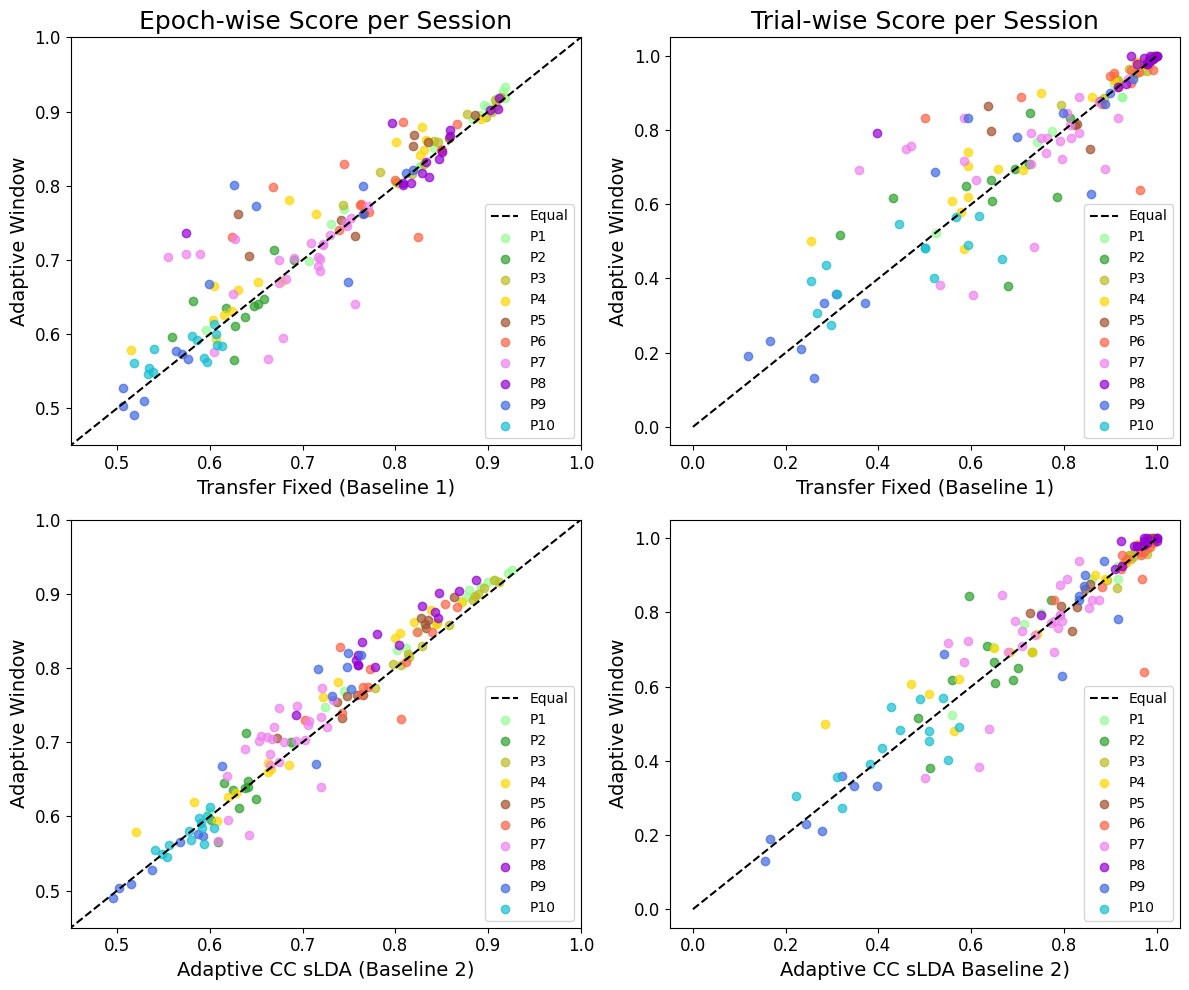

In [ ]:
# load baseline and one comparison classifier
baseline1 = pd.read_csv(directory+"transferdata.csv")
baseline2 = pd.read_csv(directory+"aphasia_sldadata.csv")
clf_A = pd.read_csv(directory+"window5data.csv")

# calculate differences
ews_diff1 = clf_A["ews"] - baseline1["ews"]
tws_diff1 = clf_A["tws"] - baseline1["tws"]
ews_diff2 = clf_A["ews"] - baseline2["ews"]
tws_diff2 = clf_A["tws"] - baseline2["tws"]

def print_summary(metric_name, diffs):
    print(f"--- {metric_name} ---")
    print(f"Mean difference: {diffs.mean():.4f}")
    print(f"Median difference: {diffs.median():.4f}")
    print(f"Std deviation: {diffs.std():.4f}")
    print(f"Min/Max: {diffs.min():.4f} / {diffs.max():.4f}")
    print(f"Improved sessions: {(diffs > 0).sum()} / {len(diffs)}")
    print(f"Wilcoxon signed-rank test: p-value = {wilcoxon(diffs).pvalue:.4g}")
    print()
    

print_summary("EWS: Window BT-LDA - Baseline 1", ews_diff1)
print_summary("TWS: Window BT_LDA - Baseline 1", tws_diff1)
print_summary("EWS: Window BT-LDA - Baseline 2", ews_diff2)
print_summary("TWS: Window BT_LDA - Baseline 2", tws_diff2)

# colors = ['palegreen',
#           'tab:orange',
#           'tab:green',
#           'red',
#           'pink',
#           'tab:brown',
#           'purple',
#           'blue',
#           'tab:olive',
#           'tab:cyan'
# ]
colors = ['palegreen',
          'tab:green',
          'tab:olive',
          #'tab:orange',
          'gold',
          'sienna',
          #'red',
          'tomato',
          'violet',
          'darkviolet',
          'royalblue',
          'tab:cyan'
]

# First baseline 
# plot 1: ews
fig,axs = plt.subplots(2,2, figsize=(12,10))
axs[0,0].plot([0, 1], [0, 1], '--', label="Equal", color="black")
for p in np.arange(1,11):
    axs[0,0].scatter(baseline1["ews"][baseline1['patient'].isin([p])], clf_A["ews"][clf_A['patient'].isin([p])],alpha=0.7,label=f"P{p}", color=colors[p-1])

axs[0,0].set_xlabel("Transfer Fixed (Baseline 1)", fontsize=14)
axs[0,0].set_ylabel("Adaptive Window", fontsize=14)
axs[0,0].set_xlim(0.45,1)
axs[0,0].set_ylim(0.45,1)
axs[0,0].tick_params(axis='x',labelsize=12)
axs[0,0].tick_params(axis='y',labelsize=12)
axs[0,0].set_title("Epoch-Wise Score per Session", fontsize=18)
axs[0,0].legend(loc='lower right')

# plot 2: tws
axs[0,1].plot([0, 1], [0, 1], '--', label="Equal", color="black")
for p in np.arange(1,11):
    axs[0,1].scatter(baseline1["tws"][baseline1['patient'].isin([p])], clf_A["tws"][clf_A['patient'].isin([p])],alpha=0.7,label=f"P{p}", color=colors[p-1])
axs[0,1].set_xlabel("Transfer Fixed (Baseline 1)", fontsize=14)
axs[0,1].set_ylabel("Adaptive Window", fontsize=14)
axs[0,1].tick_params(axis='x',labelsize=12)
axs[0,1].tick_params(axis='y',labelsize=12)

axs[0,1].set_title("Trial-Wise Score per Session", fontsize=18)
axs[0,1].legend(loc='lower right')

# Second baseline 
# plot 3: ews
axs[1,0].plot([0, 1], [0, 1], '--', label="Equal", color="black")
for p in np.arange(1,11):
    axs[1,0].scatter(baseline2["ews"][baseline2['patient'].isin([p])], clf_A["ews"][clf_A['patient'].isin([p])],alpha=0.7,label=f"P{p}", color=colors[p-1])

axs[1,0].set_xlabel("Adaptive CC sLDA (Baseline 2)", fontsize=14)
axs[1,0].set_ylabel("Adaptive Window", fontsize=14)
axs[1,0].set_xlim(0.45,1)
axs[1,0].set_ylim(0.45,1)
axs[1,0].tick_params(axis='x',labelsize=12)
axs[1,0].tick_params(axis='y',labelsize=12)
#axs[1,0].set_title("Epoch-wise Score per Session", fontsize=16)
axs[1,0].legend(loc='lower right')

# plot 4: tws
axs[1,1].plot([0, 1], [0, 1], '--', label="Equal", color="black")
for p in np.arange(1,11):
    axs[1,1].scatter(baseline2["tws"][baseline2['patient'].isin([p])], clf_A["tws"][clf_A['patient'].isin([p])],alpha=0.7,label=f"P{p}",color=colors[p-1])
axs[1,1].set_xlabel("Adaptive CC sLDA Baseline 2)", fontsize=14)
axs[1,1].set_ylabel("Adaptive Window", fontsize=14)
axs[1,1].tick_params(axis='x',labelsize=12)
axs[1,1].tick_params(axis='y',labelsize=12)

#axs[1,1].set_title("Trial-wise Score per Session", fontsize=16)
axs[1,1].legend(loc='lower right')

plt.savefig("window5050plot.svg", bbox_inches="tight")
plt.savefig("window5050plot.pdf", bbox_inches="tight")
plt.savefig("window5050plot.png", dpi=600, bbox_inches="tight")

plt.tight_layout()
plt.show()



In [47]:

plt.figure(figsize=(18,10))
#plt.plot(ews_avg_static, label="Static Fixed", linestyle='dashed')
# plt.plot([np.mean(l) for l in t1_scores],label="t1 scores", color="green")
# plt.plot([np.mean(l) for l in w3_scores],label="w3 scores", color="pink")

plt.scatter(y=[np.mean(l) for l in t2_ews_scores], x=np.arange(0,10),label="t2 scores avg per patient", color="blue", linestyle="dashed")
plt.scatter(y=[np.mean(l) for l in w4_ews_scores],x=np.arange(0,10), label="w4 scores avg per patient", color="red", linestyle="dashed")
plt.scatter(y=[np.mean(l) for l in cc2_ews_scores],x=np.arange(0,10), label="cc2 scores avg per patient", color="orange", linestyle="dashed")

# plt.plot(ews_avg_transfer, label="Transfer Fixed-V1 (s)", color="tab:blue")
# plt.plot(ews_avg_window_v3, label="Window v3 (s)", color="red")

# plt.plot(ews_avg_transfer_v2, label="Transfer Fixed V2 (l) avg per session", color="tab:blue",linestyle='dashed')
# plt.plot(ews_avg_window_v4, label="Window v4 (l) avg per session", color="red",linestyle='dashed')
plt.ylabel("Epoch-wise accuracy")
plt.xlabel('Patient')
#plt.ylim(0.1,1)
# plt.xticks(np.arange(0,25), np.arange(3,28))  
plt.xticks(np.arange(0,10), np.arange(1,11))  
plt.legend()    
plt.title("Grand average epoch-wise accuracy")   
plt.grid() 
plt.show()

NameError: name 't2_ews_scores' is not defined

<Figure size 1800x1000 with 0 Axes>

## Learning curves of all patients

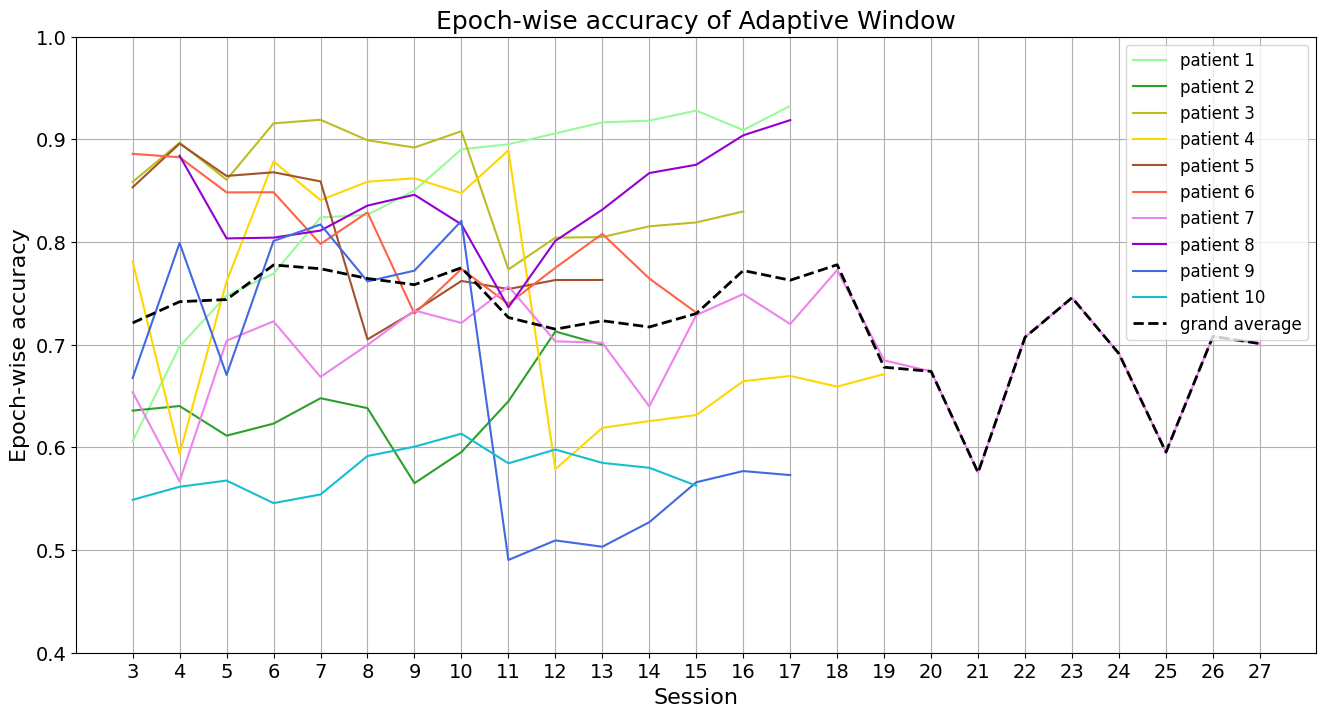

In [96]:
#ews_all_transfer = get_scores_all_patients()
#acc_all_patients = ews_all_transfer
#grand_avg = ews_avg_transfer

# for p in np.arange(1,11):
#     axs[0,0].scatter(baseline1["ews"][baseline1['patient'].isin([p])], clf_A["ews"][clf_A['patient'].isin([p])],alpha=0.7,label=f"P{p}", color=colors[p-1])

baseline1 = pd.read_csv(directory+"transferdata.csv")
baseline2 = pd.read_csv(directory+"aphasia_sldadata.csv")
clf_A = pd.read_csv(directory+"window5data.csv")
clf_B = pd.read_csv(directory+"ccdata.csv")

classifier = clf_A
clf_name = "Adaptive Window"
grand_avg = classifier.groupby('session')['ews'].mean().reset_index()
save_as = "ewslearningcurvewindowbtlda"


title=f"Epoch-wise accuracy of {clf_name}"
ylabel="Epoch-wise accuracy"

ylim=(0.4,1)
colors = ['palegreen',
          'tab:green',
          'tab:olive',
          #'tab:orange',
          'gold',
          'sienna',
          #'red',
          'tomato',
          'violet',
          'darkviolet',
          'royalblue',
          'tab:cyan'
]
#colors=['lightblue','lightblue','blue','violet','lightgreen','green','tomato', 'darkblue', 'grey', 'gold', 'rosybrown']

plt.figure(figsize=(16,8))
for p in range (1,11):
    color = colors[p-1]
    y = classifier["ews"][classifier['patient'].isin([p])]
    if p!=8:
        plt.plot(np.arange(0,len(y)), y, label=f"patient {p}", color=color)
    else:
        plt.plot(np.arange(1,len(y)), y[:-1], label=f"patient {p}", color=color)

plt.plot(grand_avg['ews'], label="grand average", color = 'black', linewidth=2, linestyle='dashed')        
plt.ylabel(ylabel, fontsize=16)
plt.xlabel('Session', fontsize=16)
plt.ylim(ylim)
plt.xticks(np.arange(0,25), np.arange(3,28),fontsize=14)    
plt.yticks(fontsize=14)
plt.legend(fontsize=12)    
plt.title(title, fontsize=18)   
plt.grid() 


plt.savefig(f"{save_as}.svg", bbox_inches="tight")
plt.savefig(f"{save_as}.pdf", bbox_inches="tight")
plt.savefig(f"{save_as}.png", dpi=600, bbox_inches="tight")

plt.show()




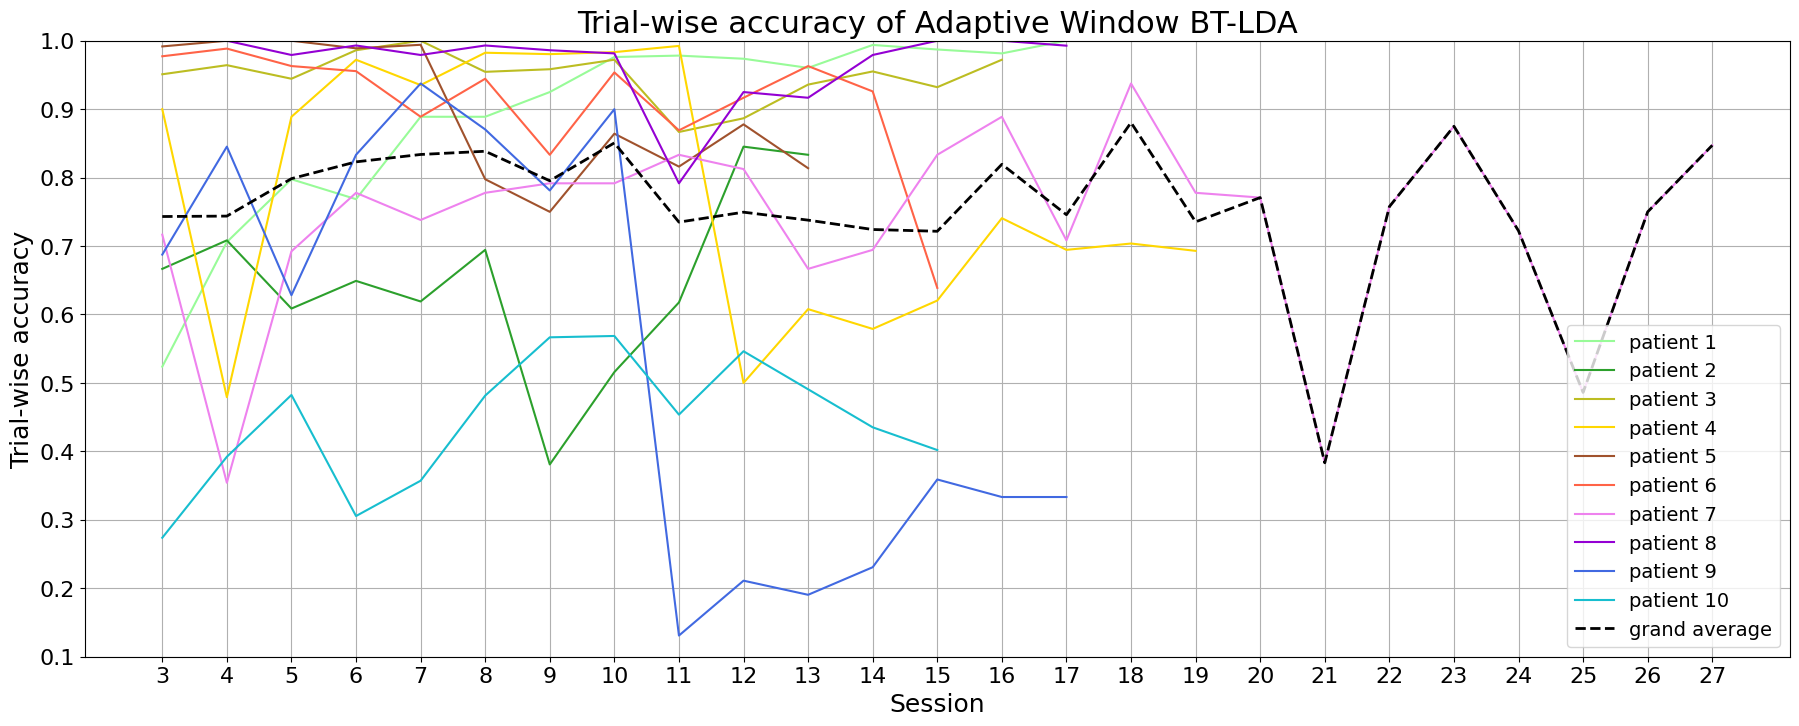

In [120]:
baseline1 = pd.read_csv(directory+"transferdata.csv")
baseline2 = pd.read_csv(directory+"aphasia_sldadata.csv")
clf_A = pd.read_csv(directory+"window5data.csv")
clf_B = pd.read_csv(directory+"ccdata.csv")

classifier = clf_A
clf_name = "Adaptive Window BT-LDA"
grand_avg = classifier.groupby('session')['tws'].mean().reset_index()
save_as = "twslearningcurvewindow"


title=f"Trial-wise accuracy of {clf_name}"
ylabel="Trial-wise accuracy"

colors = ['palegreen',
          'tab:green',
          'tab:olive',
          #'tab:orange',
          'gold',
          'sienna',
          #'red',
          'tomato',
          'violet',
          'darkviolet',
          'royalblue',
          'tab:cyan'
]
#colors=['lightblue','lightblue','blue','violet','lightgreen','green','tomato', 'darkblue', 'grey', 'gold', 'rosybrown']

plt.figure(figsize=(22,8))
for p in range (1,11):
    color = colors[p-1]
    y = classifier["tws"][classifier['patient'].isin([p])]
    if p!=8:
        plt.plot(np.arange(0,len(y)), y, label=f"patient {p}", color=color)
    else:
        plt.plot(np.arange(1,len(y)), y[:-1], label=f"patient {p}", color=color)

plt.plot(grand_avg['tws'], label="grand average", color = 'black', linewidth=2, linestyle='dashed')        
plt.ylabel(ylabel, fontsize=18)
plt.xlabel('Session', fontsize=18)
plt.xticks(np.arange(0,25), np.arange(3,28),fontsize=16)    
plt.yticks(fontsize=16)
plt.ylim(0.1,1)
plt.legend(fontsize=14)    
plt.title(title, fontsize=22)   
plt.grid() 


plt.savefig(f"{save_as}.svg", bbox_inches="tight")
plt.savefig(f"{save_as}.pdf", bbox_inches="tight")
plt.savefig(f"{save_as}.png", dpi=600, bbox_inches="tight")

plt.show()




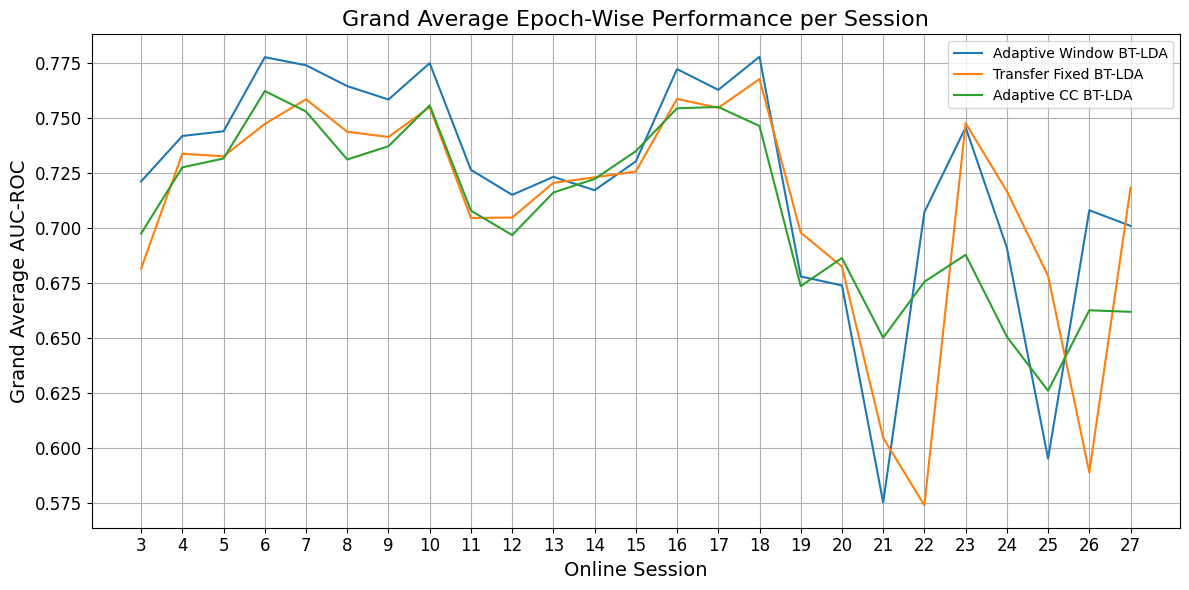

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
# Group by session and compute the mean EWS per session
directory = "storage/classifiers/"
df = pd.read_csv(directory+'window5data.csv')
avg_ews_window = df.groupby('session')['ews'].mean().reset_index()
avg_tws_window = df.groupby('session')['tws'].mean().reset_index()

df = pd.read_csv(directory+'transferdata.csv')
avg_ews_transfer = df.groupby('session')['ews'].mean().reset_index()
avg_tws_transfer = df.groupby('session')['tws'].mean().reset_index()

df = pd.read_csv(directory+'ccdata.csv')
avg_ews_cc = df.groupby('session')['ews'].mean().reset_index()
avg_tws_cc = df.groupby('session')['tws'].mean().reset_index()

df = pd.read_csv(directory+'aphasia_sldadata.csv')
avg_ews_slda = df.groupby('session')['ews'].mean().reset_index()
avg_tws_slda = df.groupby('session')['tws'].mean().reset_index()

df = pd.read_csv(directory+'staticdata.csv')
avg_ews_static = df.groupby('session')['ews'].mean().reset_index()
avg_tws_static = df.groupby('session')['tws'].mean().reset_index()


# Plotting
plt.figure(figsize=(12, 6))
plt.plot(avg_ews_window['session'], avg_ews_window['ews'], label='Adaptive Window BT-LDA')
plt.plot(avg_ews_transfer['session'], avg_ews_transfer['ews'], label='Transfer Fixed BT-LDA')
plt.plot(avg_ews_cc['session'], avg_ews_cc['ews'], label='Adaptive CC BT-LDA')
#plt.plot(avg_ews_slda['session'], avg_ews_slda['ews'], label='Adaptive CC sLDA')

plt.xlabel('Online Session', fontsize=14)           # bigger fontsize
plt.ylabel('Grand Average AUC-ROC', fontsize=14)
plt.title('Grand Average Epoch-Wise Performance per Session', fontsize=16)
plt.grid(True)
plt.xticks(avg_ews_transfer['session'], fontsize=12)
plt.yticks(fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()


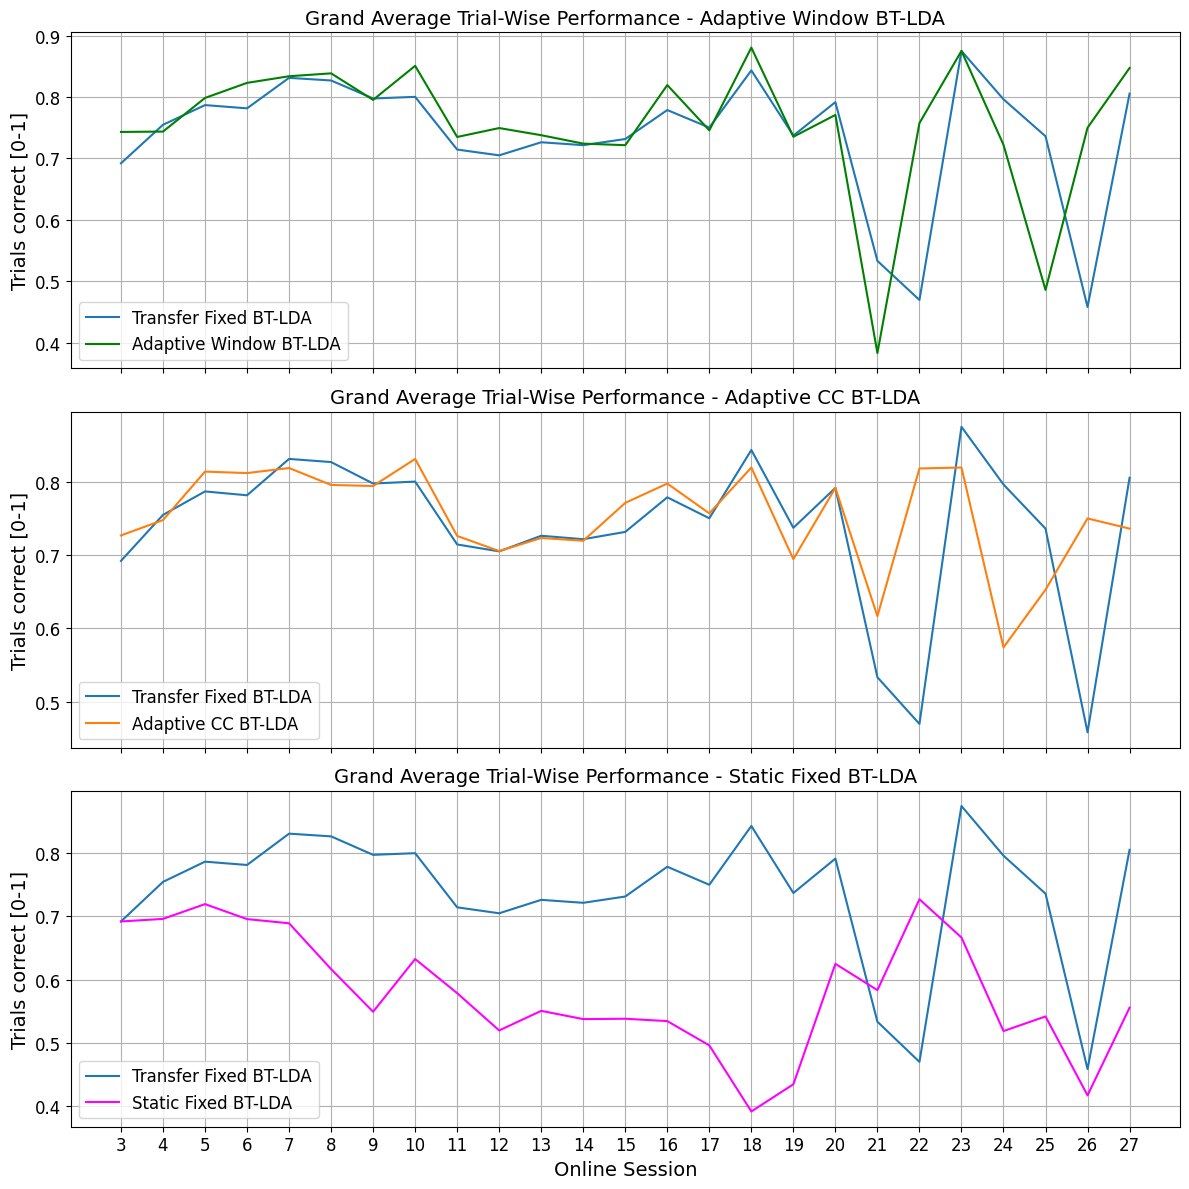

In [132]:
# First subplot
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
axs[0].plot(avg_tws_transfer['session'], avg_tws_transfer['tws'], label='Transfer Fixed BT-LDA')
axs[0].plot(avg_tws_window['session'], avg_tws_window['tws'], label='Adaptive Window BT-LDA', color="green")
axs[0].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[0].set_title('Grand Average Trial-Wise Performance - Adaptive Window BT-LDA', fontsize=14)
axs[0].grid(True)
axs[0].legend(fontsize=12)
axs[0].tick_params(axis='y', labelsize=12)

# Second subplot
axs[1].plot(avg_tws_transfer['session'], avg_tws_transfer['tws'], label='Transfer Fixed BT-LDA')
axs[1].plot(avg_tws_cc['session'], avg_tws_cc['tws'], label='Adaptive CC BT-LDA')
axs[1].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[1].set_title('Grand Average Trial-Wise Performance - Adaptive CC BT-LDA', fontsize=14)
axs[1].grid(True)
axs[1].legend(fontsize=12)
axs[1].tick_params(axis='y', labelsize=12)

# Third subplot
axs[2].plot(avg_tws_transfer['session'], avg_tws_transfer['tws'], label='Transfer Fixed BT-LDA')
axs[2].plot(avg_tws_static['session'], avg_tws_static['tws'], label='Static Fixed BT-LDA', color="magenta")
axs[2].set_xlabel('Online Session', fontsize=14)
axs[2].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[2].set_title('Grand Average Trial-Wise Performance - Static Fixed BT-LDA', fontsize=14)
axs[2].grid(True)
axs[2].legend(fontsize=12)
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].set_xticks(avg_tws_transfer['session'])


plt.savefig("TWS_grandavgsessions_3plots.svg", bbox_inches="tight")
plt.savefig("TWS_grandavgsessions_3plots.pdf", bbox_inches="tight")
plt.savefig("TWS_grandavgsessions_3plots.png", dpi=600, bbox_inches="tight")

plt.tight_layout()
plt.show()

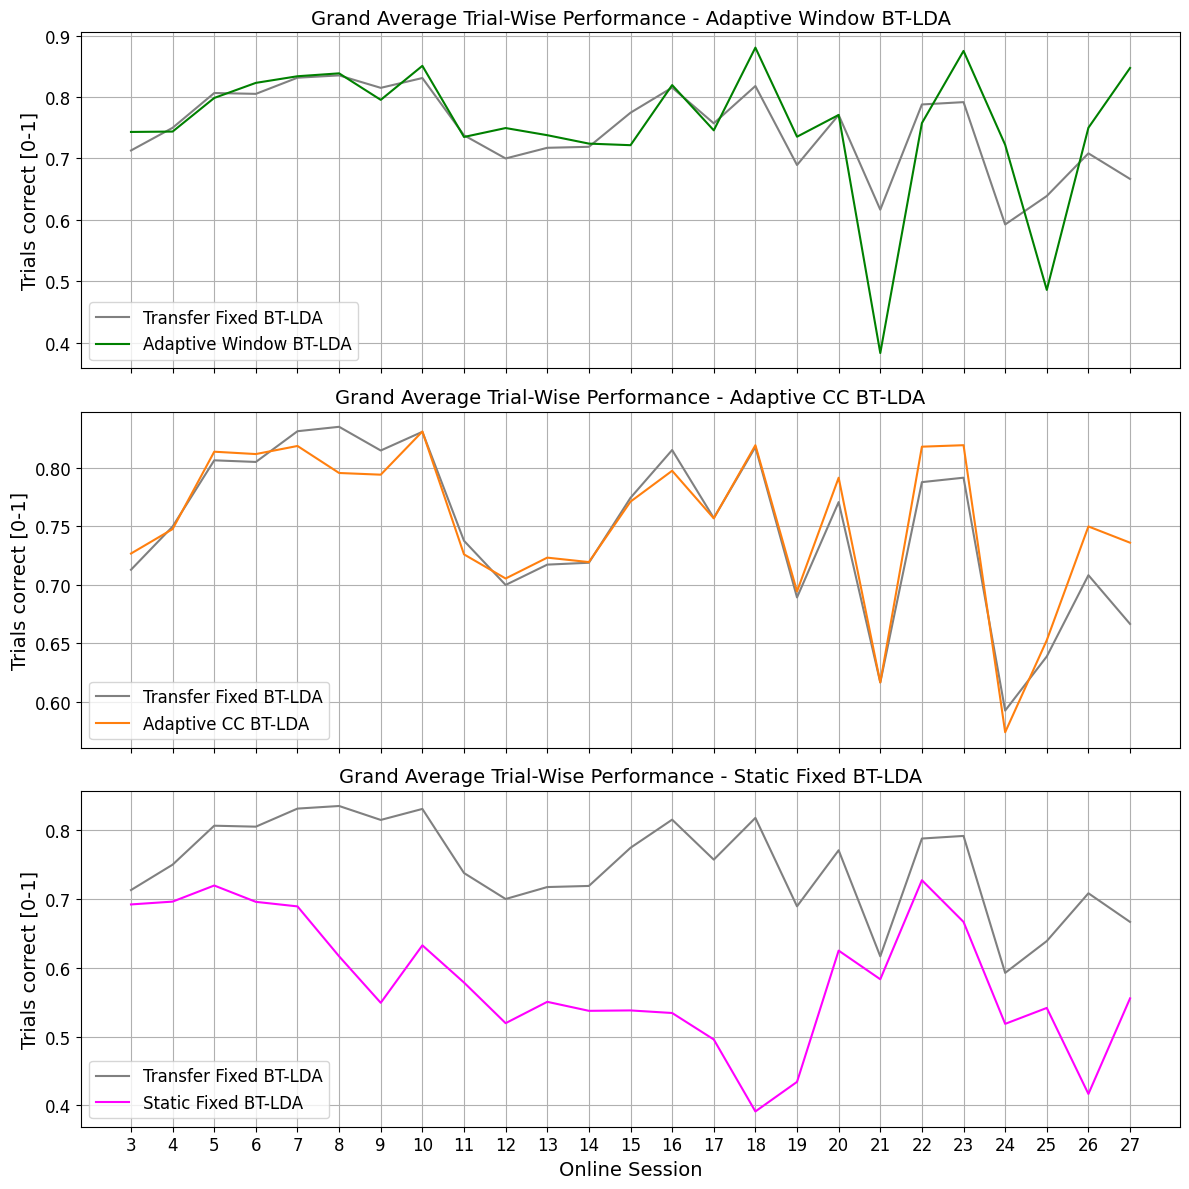

In [131]:
# First subplot
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
axs[0].plot(avg_tws_slda['session'], avg_tws_slda['tws'], label='Transfer Fixed BT-LDA', color="grey")
axs[0].plot(avg_tws_window['session'], avg_tws_window['tws'], label='Adaptive Window BT-LDA', color="green")
axs[0].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[0].set_title('Grand Average Trial-Wise Performance - Adaptive Window BT-LDA', fontsize=14)
axs[0].grid(True)
axs[0].legend(fontsize=12)
axs[0].tick_params(axis='y', labelsize=12)

# Second subplot
axs[1].plot(avg_tws_slda['session'], avg_tws_slda['tws'], label='Transfer Fixed BT-LDA', color="grey")
axs[1].plot(avg_tws_cc['session'], avg_tws_cc['tws'], label='Adaptive CC BT-LDA',color="tab:orange")
axs[1].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[1].set_title('Grand Average Trial-Wise Performance - Adaptive CC BT-LDA', fontsize=14)
axs[1].grid(True)
axs[1].legend(fontsize=12)
axs[1].tick_params(axis='y', labelsize=12)

# Third subplot
axs[2].plot(avg_tws_slda['session'], avg_tws_slda['tws'], label='Transfer Fixed BT-LDA',color="grey")
axs[2].plot(avg_tws_static['session'], avg_tws_static['tws'], label='Static Fixed BT-LDA', color="magenta")
axs[2].set_xlabel('Online Session', fontsize=14)
axs[2].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[2].set_title('Grand Average Trial-Wise Performance - Static Fixed BT-LDA', fontsize=14)
axs[2].grid(True)
axs[2].legend(fontsize=12)
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].set_xticks(avg_tws_slda['session'])


plt.savefig("TWS_SLDAgrandavgsessions_3plots.svg", bbox_inches="tight")
plt.savefig("TWS_SLDAgrandavgsessions_3plots.pdf", bbox_inches="tight")
plt.savefig("TWS_SLDAgrandavgsessions_3plots.png", dpi=600, bbox_inches="tight")

plt.tight_layout()
plt.show()

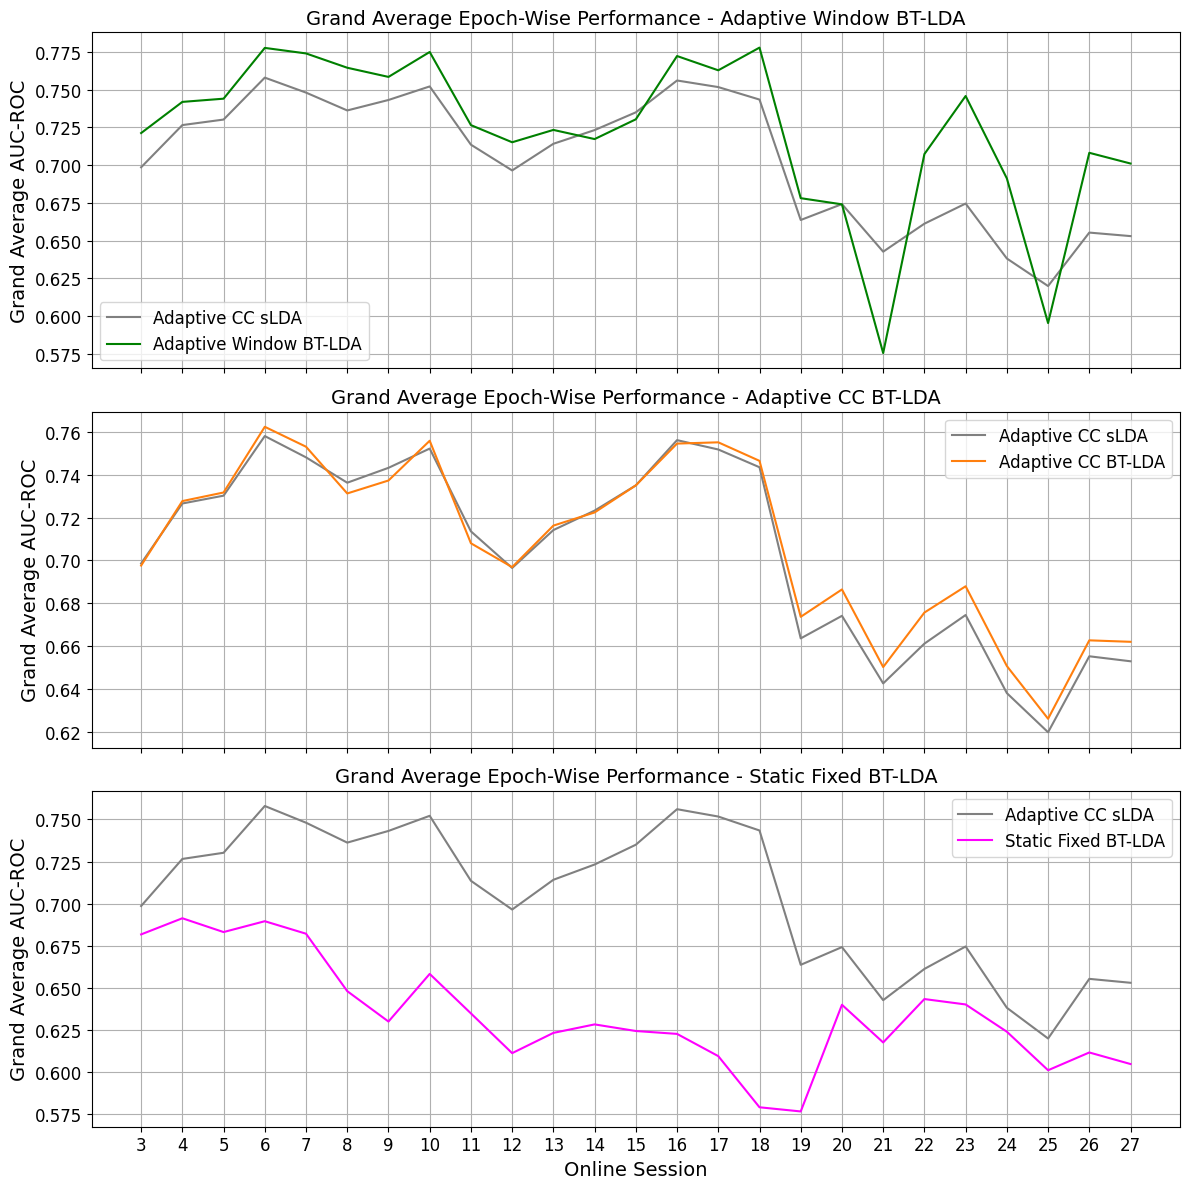

In [ ]:
# First subplot
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
axs[0].plot(avg_ews_slda['session'], avg_ews_slda['ews'], label='Adaptive CC sLDA', color="grey")
axs[0].plot(avg_ews_window['session'], avg_ews_window['ews'], label='Adaptive Window BT-LDA', color="green")
axs[0].set_ylabel('Grand Average AUC-ROC', fontsize=14)
axs[0].set_title('Grand Average Epoch-Wise Performance - Adaptive Window BT-LDA', fontsize=14)
axs[0].grid(True)
axs[0].legend(fontsize=12)
axs[0].tick_params(axis='y', labelsize=12)

# Second subplot
axs[1].plot(avg_ews_slda['session'], avg_ews_slda['ews'], label='Adaptive CC sLDA',color="grey")
axs[1].plot(avg_ews_cc['session'], avg_ews_cc['ews'], label='Adaptive CC BT-LDA', color="tab:orange")
axs[1].set_ylabel('Grand Average AUC-ROC', fontsize=14)
axs[1].set_title('Grand Average Epoch-Wise Performance - Adaptive CC BT-LDA', fontsize=14)
axs[1].grid(True)
axs[1].legend(fontsize=12)
axs[1].tick_params(axis='y', labelsize=12)

# Third subplot
axs[2].plot(avg_ews_slda['session'], avg_ews_slda['ews'], label='Adaptive CC sLDA',color="grey")
axs[2].plot(avg_ews_static['session'], avg_ews_static['ews'], label='Static Fixed BT-LDA', color="magenta")
axs[2].set_xlabel('Online Session', fontsize=14)
axs[2].set_ylabel('Grand Average AUC-ROC', fontsize=14)
axs[2].set_title('Grand Average Epoch-Wise Performance - Static Fixed BT-LDA', fontsize=14)
axs[2].grid(True)
axs[2].legend(fontsize=12)
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].set_xticks(avg_ews_transfer['session'])


# plt.savefig("slda_grandavgsessions_3plots.svg", bbox_inches="tight")
# plt.savefig("slda_grandavgsessions_3plots.pdf", bbox_inches="tight")
# plt.savefig("slda_grandavgsessions_3plots.png", dpi=600, bbox_inches="tight")

plt.tight_layout()
plt.show()

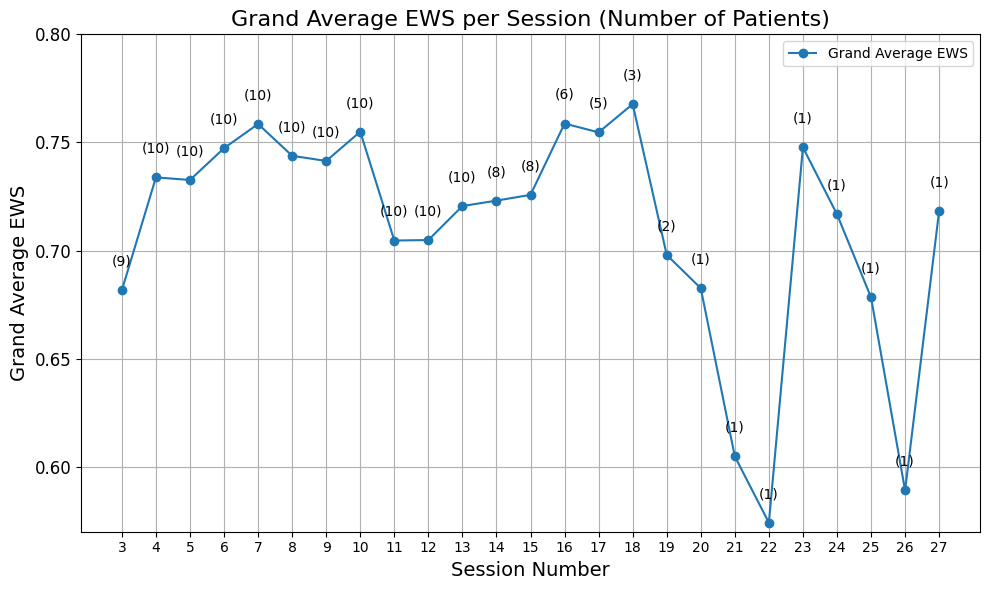

In [110]:
# Calculate number of patients per session
df = pd.read_csv('transferdata.csv')
avg_ews_transfer = df.groupby('session')['ews'].mean().reset_index()

counts = df.groupby('session')['patient'].nunique().reset_index()
counts.columns = ['session', 'n_patients']

# Merge with average EWS
avg_ews_transfer = df.groupby('session')['ews'].mean().reset_index()
avg_ews = avg_ews_transfer.merge(counts, on='session')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(avg_ews['session'], avg_ews['ews'], marker='o', label='Grand Average EWS')

for i, row in avg_ews.iterrows():
    plt.text(row['session'], row['ews'] + 0.01, f"({int(row['n_patients'])})", 
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Session Number', fontsize=14)
plt.ylabel('Grand Average EWS', fontsize=14)
plt.title('Grand Average EWS per Session (Number of Patients)', fontsize=16)
plt.grid(True)
plt.xticks(avg_ews['session'])
plt.yticks(fontsize=12)
plt.ylim(0.57,0.8)
plt.legend()
plt.tight_layout()


plt.savefig("patientnr_grandavgsessions.svg", bbox_inches="tight")
plt.savefig("patientnr_grandavgsessions.pdf", bbox_inches="tight")
plt.savefig("patientnr_grandavgsessions.png", dpi=600, bbox_inches="tight")

plt.show()


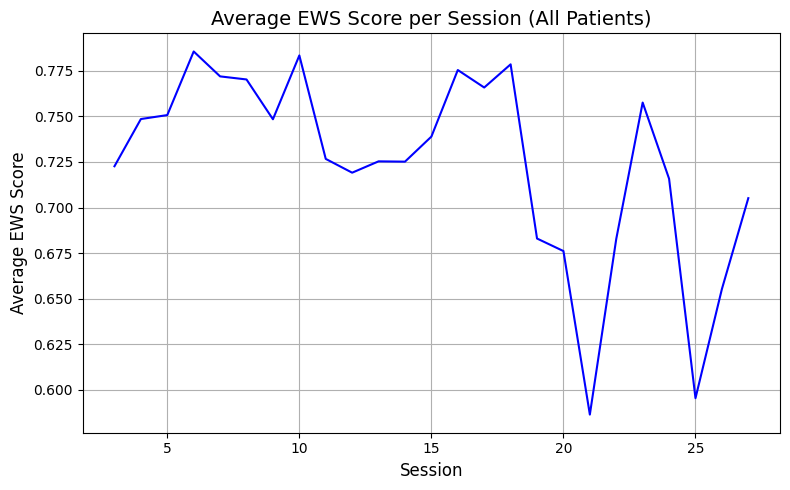

In [ ]:
# Read the CSV file
df = pd.read_csv("window4data.csv") 

# Group by session and compute the mean EWS score
avg_ews_per_session = df.groupby('session')['ews'].mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(avg_ews_per_session.index, avg_ews_per_session.values, color='blue')
plt.xlabel("Session", fontsize=12)
plt.ylabel("Average EWS Score", fontsize=12)
plt.title("Average EWS Score per Session (All Patients)", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:

plot_all_patients(ews_all_static, grand_avg=ews_avg_static, title="Epoch-wise accuracy of Static Fixed BT-LDA", ylabel="Epoch-wise accuracy")

NameError: name 'ews_all_static' is not defined